# 02 – Data Preprocessing

**Goal:** Turn the raw airport weather records into a clean table with one row per hour.

**Why this matters:** Machine learning models can only learn from clean, evenly spaced data.
Our raw data has bad readings, missing values, and irregular timestamps.

**Steps in this notebook:**
1. Load the raw KUNV data and keep only columns our device can measure (temperature, humidity, pressure).
2. Remove impossible pressure readings (marked as missing, not deleted).
3. Convert pressure from inches of mercury to hPa, the unit our sensor reports.
4. Combine irregular observations into one reading per hour.
5. Fill gaps of 3 hours or less. Longer gaps stay empty, because guessing would invent data.
6. Save the cleaned table to `data/processed/`.

**Key idea:** Precipitation is only used to create the answer key (labels), never as a model input,
because our handheld device has no rain sensor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv("../data/raw/UNV_asos_2015_2025.csv", low_memory=False)
df["valid"] = pd.to_datetime(df["valid"])

d = df[["valid", "tmpf", "dwpf", "relh", "alti", "wxcodes"]].copy()

# 1) Impossible pressure readings -> NaN (missing), not deleted
bad = (d["alti"] < 28.5) | (d["alti"] > 31.5)
print("Set to NaN:", bad.sum())
d.loc[bad, "alti"] = np.nan

# 2) Convert units AFTER cleaning
d["pressure_hpa"] = d["alti"] * 33.8639

# 3) Precipitation flag from weather codes (same logic as before)
# RA = RAIN, DZ = Drizzle, SN = Snow, SG = Snow Grains, PL = Ice Pellets (Sleet), GR = Hail, GS = Small Hail
# UP = Unknown Precipitation, SH = Showers, TS = Thunderstorm
PRECIP = ("RA", "DZ", "SN", "SG", "PL", "GR", "GS", "UP", "SH", "TS")

def has_precip(w):
    if not isinstance(w, str):
        return False
    for tok in w.split(): # ASOS weather codes can chain multiple conditions together separated by spaces, so we'll look at each one split
        tok = tok.lstrip("+-") # Codes use + for heavy intensity, and - for light intensity. We ignore these to just see the code itself
        if tok.startswith("VC"): # VC means in the vicinity, so since its not directly over our location we ignore
            continue
        if any(code in tok for code in PRECIP):
            return True
    return False

d["precip_now"] = d["wxcodes"].apply(has_precip).astype(float)
d = d.set_index("valid").sort_index()

Set to NaN: 11


In [2]:
sensor_cols = ["tmpf", "dwpf", "relh", "pressure_hpa"]

hourly = d[sensor_cols].resample("1h").mean()
hourly["precip"] = d["precip_now"].resample("1h").max()

print("Hourly rows:", len(hourly))
print(hourly.isna().sum())

Hourly rows: 96432
tmpf            2100
dwpf            2110
relh            2156
pressure_hpa    2076
precip          2017
dtype: int64


In [3]:
def fill_short_gaps(series, max_gap=3):
    """Linearly interpolate missing values, but ONLY inside gaps of
    max_gap hours or shorter. Longer gaps stay completely empty (NaN),
    because guessing across a long outage would be inventing data."""
    is_missing = series.isna()

    # Give every run of consecutive "missing" or "present" values its own ID number
    run_id = (is_missing != is_missing.shift()).cumsum()

    # For each run, count how many missing values it has (= length of the gap)
    gap_length = is_missing.groupby(run_id).transform("sum")

    # limit_area="inside" stops pandas from filling past the ends of the data
    interpolated = series.interpolate(method="time", limit_area="inside")

    # Keep an interpolated value only where the gap is short
    short_gap = is_missing & (gap_length <= max_gap)
    return series.where(~short_gap, interpolated)

for col in ["tmpf", "dwpf", "relh", "pressure_hpa"]:
    hourly[col] = fill_short_gaps(hourly[col], max_gap=3)

print(hourly.isna().sum())

tmpf             994
dwpf             994
relh            1036
pressure_hpa     992
precip          2017
dtype: int64


Fraction of known hours with precipitation: 0.122


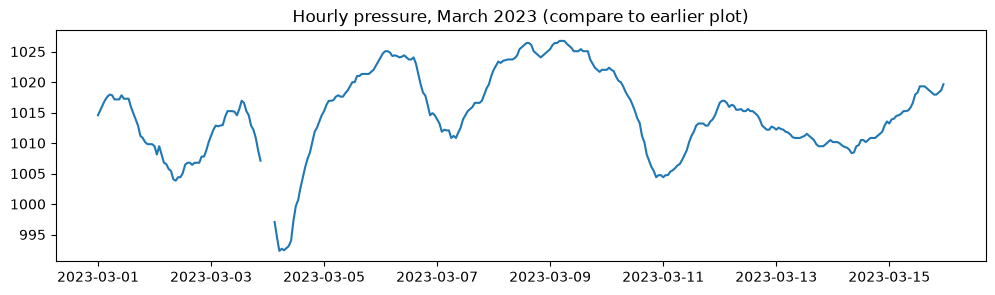

In [4]:
print("Fraction of known hours with precipitation:",
      hourly["precip"].mean().round(3))

fig, ax = plt.subplots(figsize=(12, 3))
sub = hourly.loc["2023-03-01":"2023-03-15", "pressure_hpa"]
ax.plot(sub.index, sub.values)
ax.set_title("Hourly pressure, March 2023 (compare to earlier plot)")
plt.show()

Path("../data/processed").mkdir(parents=True, exist_ok=True)
hourly.to_csv("../data/processed/unv_hourly_clean.csv")

In [5]:
HORIZON_HOURS = 3   # how far ahead we predict. Change this one number to try 1 h or 6 h.

# shift(-k) pulls the value from k hours IN THE FUTURE up into the current row.
# We stack the next 1, 2, and 3 hours side by side, then ask: did ANY of them have precipitation?
future_columns = [hourly["precip"].shift(-k) for k in range(1, HORIZON_HOURS + 1)]
hourly["precip_next_3h"] = pd.concat(future_columns, axis=1).max(axis=1, skipna=False)
# skipna=False means: if any of those future hours is unknown, the label is unknown (NaN),
# not silently treated as "no rain".

print(hourly["precip_next_3h"].value_counts(dropna=False))

# Persistence check: if it's precipitating NOW, how likely is it in the next 3 hours?
print(pd.crosstab(hourly["precip"], hourly["precip_next_3h"], normalize="index").round(3))

precip_next_3h
0.0    74803
1.0    17376
NaN     4253
Name: count, dtype: int64
precip_next_3h    0.0    1.0
precip                      
0.0             0.896  0.104
1.0             0.209  0.791


So earlier we did some data cleaning removing bad sensor readings for pressure that were too low or too high (because they were physically impossible for State College, PA). However, that doesn't remove all pressure readings because some readings show a perfectly normal pressure by itself, but relative to the hours around it, it is impossible. For example, pressure should increase or decrease smoothly, not spike because no weather system can do that.

So the next step is dealing with these bad pressure readings relative to the hours around it. To do this, we are going to take the rolling median.

In [6]:
def remove_spikes(series, window=9, max_dev=5.0):
    """Mark readings as missing (NaN) if they differ from the median of
    their surrounding hours by more than max_dev.

    window  : how many hours to look at, centered on each reading (9 = 4 before, 4 after)
    max_dev : biggest believable distance from that local median (hPa)

    We use the MEDIAN instead of the average because a few bad values
    drag an average toward them, but barely move a median.
    """
    local_median = series.rolling(window, center=True, min_periods=5).median()
    is_bad = (series - local_median).abs() > max_dev
    return series.mask(is_bad), is_bad

hourly["pressure_hpa"], removed = remove_spikes(hourly["pressure_hpa"])
print("Pressure readings removed as spikes:", removed.sum())
print(hourly.loc[removed, "pressure_hpa"].shape)   # sanity check: these are now NaN

Pressure readings removed as spikes: 22
(22,)


In [7]:
# PAST change: pressure now minus pressure 3 hours ago.
# shift(3) looks BACKWARD in time, so this is safe to use as a model INPUT.
hourly["dp_past_3h"] = hourly["pressure_hpa"] - hourly["pressure_hpa"].shift(3)

# FUTURE change: pressure 3 hours from now minus pressure now.
# shift(-3) looks FORWARD, so this can ONLY be used for labels, NEVER as an input.
# Using it as an input would be data leakage: the model would see the future during training
# and score brilliantly, then fail on the real device.
hourly["dp_future_3h"] = hourly["pressure_hpa"].shift(-3) - hourly["pressure_hpa"]

print(hourly[["dp_past_3h", "dp_future_3h"]].describe().round(2))

       dp_past_3h  dp_future_3h
count    94930.00      94930.00
mean        -0.00         -0.00
std          1.49          1.49
min        -13.21        -13.21
25%         -0.90         -0.90
50%          0.00          0.00
75%          0.90          0.90
max         11.51         11.51


             mean  count
dp_past_3h              
(-20, -6]   0.888     89
(-6, -3]    0.513   2550
(-3, -1]    0.270  20413
(-1, 1]     0.157  46206
(1, 3]      0.132  19940
(3, 6]      0.187   2195
(6, 20]     0.345    110


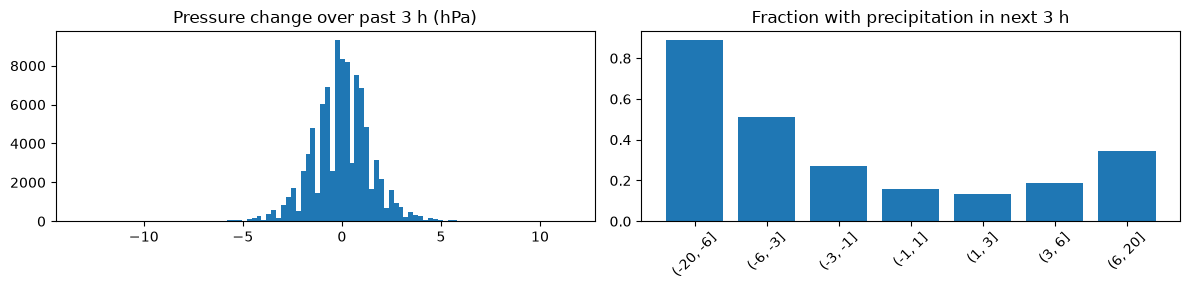

In [8]:
import matplotlib.pyplot as plt

# Group hours by how much pressure fell/rose in the PAST 3 hours,
# then compute the fraction of each group that saw precipitation in the NEXT 3 hours.
bins = [-20, -6, -3, -1, 1, 3, 6, 20]
rate = hourly.groupby(pd.cut(hourly["dp_past_3h"], bins), observed=True)["precip_next_3h"].agg(["mean", "count"])
print(rate.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].hist(hourly["dp_past_3h"].dropna(), bins=100)
ax[0].set_title("Pressure change over past 3 h (hPa)")
ax[1].bar(range(len(rate)), rate["mean"])
ax[1].set_xticks(range(len(rate)))
ax[1].set_xticklabels([str(i) for i in rate.index], rotation=45)
ax[1].set_title("Fraction with precipitation in next 3 h")
plt.tight_layout()
plt.show()

In [9]:
suspect = hourly[hourly["dp_past_3h"].abs() > 12]
print(len(suspect), "hours with a 3-hour pressure change over 12 hPa")
suspect[["pressure_hpa", "dp_past_3h"]].head(20)

1 hours with a 3-hour pressure change over 12 hPa


,pressure_hpa,dp_past_3h
valid,,
2022-01-17 06:00:00,987.245565,-13.206921


count    94930.00
mean        -0.00
std          1.49
min        -13.21
25%         -0.90
50%          0.00
75%          0.90
max         11.51
Name: dp_past_3h, dtype: float64
Hours with a 3-hour change over 12 hPa: 1


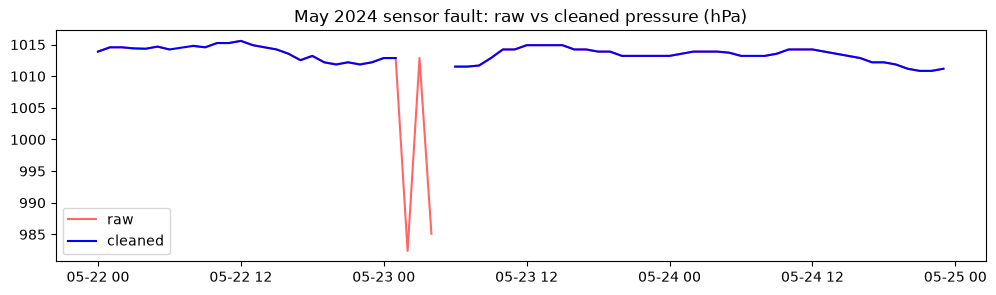

In [10]:
# 1) Did the extreme values go away?
print(hourly["dp_past_3h"].describe().round(2))
print("Hours with a 3-hour change over 12 hPa:", (hourly["dp_past_3h"].abs() > 12).sum())

# 2) Look at one of the worst episodes before/after cleaning
raw_hourly = d["pressure_hpa"].resample("1h").mean()      # untouched version for comparison
window = slice("2024-05-22", "2024-05-24")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(raw_hourly[window], label="raw", color="red", alpha=0.6)
ax.plot(hourly["pressure_hpa"][window], label="cleaned", color="blue")
ax.set_title("May 2024 sensor fault: raw vs cleaned pressure (hPa)")
ax.legend()
plt.show()